# Random Forest Smoke Detection Model

Data preparation is already done separately, so this notebook loads:

```text
iot_clean_data.xlsx
blattmann_clean_data.xlsx
```

Class mapping:

```text
0 = Normal
1 = Cooking
2 = Fire
```


#### 1. Imports


In [42]:
# Import all libraries in one place.
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


#### 2. Settings


In [43]:
# Define files, feature columns, class names, and random state.
notebook_folder = Path('.').resolve()

iot_file = notebook_folder / 'iot_clean_data.xlsx'
blattmann_file = notebook_folder / 'blattmann_clean_data.xlsx'

feature_col = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']
class_names = ['Normal', 'Cooking', 'Fire']
random_state = 42


#### 3. Load Prepared Data

We load IoT and Blattmann as separate datasets, like Felipe's model.


In [44]:
# Load the prepared IoT and Blattmann datasets separately.
iot_data = pd.read_excel(iot_file)
blattmann_data = pd.read_excel(blattmann_file, sheet_name='Blattmann Processed')

if 'label' in blattmann_data.columns:
    blattmann_data = blattmann_data.rename(columns={'label': 'blattmann_label'})

blattmann_data['class_id'] = blattmann_data['blattmann_label'].map({
    'No Smoke': 0,
    'Smoke': 2,
    'Normal': 0,
    'Fire': 2,
    0: 0,
    2: 2,
})

blattmann_data['label'] = blattmann_data['class_id'].map({
    0: 'Normal',
    2: 'Fire',
})

blattmann_data = blattmann_data.dropna(subset=['class_id'] + feature_col)
blattmann_data['class_id'] = blattmann_data['class_id'].astype(int)

print('IoT samples:', len(iot_data))
print(iot_data['label'].value_counts().to_string())

print('\nBlattmann samples:', len(blattmann_data))
print(blattmann_data['label'].value_counts().to_string())

display(iot_data.head())
display(blattmann_data.head())


IoT samples: 549
label
Cooking    329
Normal     220

Blattmann samples: 62630
label
Fire      44757
Normal    17873


,label,class_id,temperature,humidity,tvoc_ppb,eco2_ppm
0,Normal,0,21.8,32,29,413
1,Normal,0,21.8,32,35,426
2,Normal,0,21.8,32,28,409
3,Normal,0,21.8,32,25,402
4,Normal,0,21.8,32,29,413


,temperature,humidity,tvoc_ppb,eco2_ppm,blattmann_label,class_id,label
0,20.000,57.36,0,400,No Smoke,0,Normal
1,20.015,56.67,0,400,No Smoke,0,Normal
2,20.029,55.96,0,400,No Smoke,0,Normal
3,20.044,55.28,0,400,No Smoke,0,Normal
4,20.059,54.69,0,400,No Smoke,0,Normal


#### 4. Feature Distributions

This compares feature distributions by class and dataset.


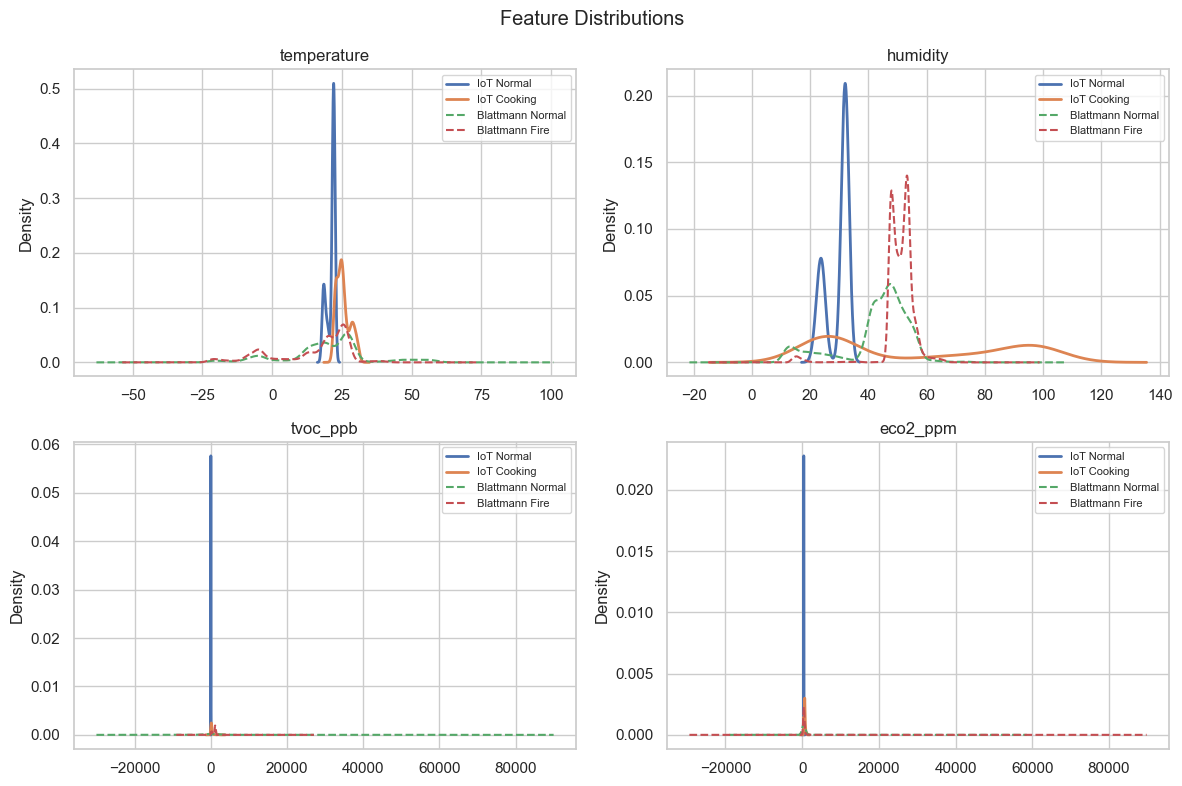

In [24]:
# Plot feature distributions per class and dataset.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions')

for ax, feature in zip(axes.flat, feature_col):
    for class_id, class_name in [(0, 'Normal'), (1, 'Cooking')]:
        values = iot_data[iot_data['class_id'] == class_id][feature]
        if len(values) > 1:
            values.plot.kde(ax=ax, label=f'IoT {class_name}', linewidth=2)

    for class_id, class_name in [(0, 'Normal'), (2, 'Fire')]:
        values = blattmann_data[blattmann_data['class_id'] == class_id][feature]
        if len(values) > 1:
            values.plot.kde(ax=ax, label=f'Blattmann {class_name}', linewidth=1.5, linestyle='--')

    ax.set_title(feature)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


#### 5. Split Each Dataset Separately

We split each dataset separately so the IoT test set is not dominated by the larger Blattmann dataset.

Then we combine only the training data.


In [28]:
# Split each dataset separately, then combine training data in memory.
X_blattmann_train, X_blattmann_test, y_blattmann_train, y_blattmann_test = train_test_split(
    blattmann_data[feature_col],
    blattmann_data['class_id'],
    test_size=0.2,
    random_state=random_state,
    stratify=blattmann_data['class_id']
)

X_iot_train, X_iot_test, y_iot_train, y_iot_test = train_test_split(
    iot_data[feature_col],
    iot_data['class_id'],
    test_size=0.2,
    random_state=random_state,
    stratify=iot_data['class_id']
)

X_train = pd.concat([X_blattmann_train, X_iot_train], ignore_index=True)
y_train = pd.concat([y_blattmann_train, y_iot_train], ignore_index=True)

print('Train:', len(y_train))
print('Blattmann test:', len(y_blattmann_test))
print('IoT test:', len(y_iot_test))

for class_id, class_name in enumerate(class_names):
    count = (y_train == class_id).sum()
    if count:
        print(f'{class_name}: {count}')


Train: 50543
Blattmann test: 12526
IoT test: 110
Normal: 14474
Cooking: 263
Fire: 35806


#### 6. Scale Features

We fit the scaler on training data only and apply it to the test sets.


In [13]:
# Fit scaler on train only — applying to test avoids data leakage, then transform both test sets.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_blattmann_test_sc = scaler.transform(X_blattmann_test)
X_iot_test_sc = scaler.transform(X_iot_test)

joblib.dump(scaler, notebook_folder / 'scaler.joblib')


['C:\\Users\\waqar\\SEP4\\System\\MlServer\\waqars_model\\scaler.joblib']

#### 7. Train Random Forest

We train one Random Forest model.

`class_weight='balanced'` helps with class imbalance.


In [36]:
# Train the Random Forest model.
random_forest = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=random_state,
    n_jobs=-1
)

random_forest.fit(X_train_sc, y_train)

joblib.dump(random_forest, notebook_folder / 'model_random_forest.joblib')


['C:\\Users\\waqar\\SEP4\\System\\MlServer\\waqars_model\\model_random_forest.joblib']

#### 8. Cross-Validation

We use 5-fold stratified cross-validation with `f1_macro`.


Cross-validation F1-macro: 0.9943 +/- 0.0033


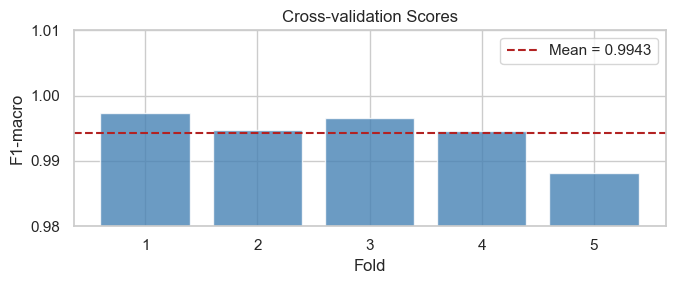

In [37]:
# Run cross-validation on the training data.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
cv_scores = cross_val_score(random_forest, X_train_sc, y_train, cv=skf, scoring='f1_macro')

print(f'Cross-validation F1-macro: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

plt.figure(figsize=(7, 3))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8)
plt.axhline(cv_scores.mean(), color='firebrick', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.ylim(0.98, 1.01)
plt.xlabel('Fold')
plt.ylabel('F1-macro')
plt.title('Cross-validation Scores')
plt.legend()
plt.tight_layout()
plt.show()


#### 9. Test Set Evaluation

We evaluate separately on Blattmann test data and IoT test data.


In [38]:
# Predict and evaluate on both test sets.
y_blattmann_pred = random_forest.predict(X_blattmann_test_sc)
y_iot_pred = random_forest.predict(X_iot_test_sc)

print('Blattmann test set')
print(classification_report(y_blattmann_test, y_blattmann_pred, target_names=class_names, labels=[0, 1, 2], zero_division=0))

print('IoT test set')
print(classification_report(y_iot_test, y_iot_pred, target_names=class_names, labels=[0, 1, 2], zero_division=0))



Blattmann test set
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      3575
     Cooking       0.00      0.00      0.00         0
        Fire       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       0.66      0.66      0.66     12526
weighted avg       1.00      1.00      1.00     12526

IoT test set
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        44
     Cooking       1.00      0.98      0.99        66
        Fire       0.00      0.00      0.00         0

    accuracy                           0.99       110
   macro avg       0.66      0.66      0.66       110
weighted avg       0.99      0.99      0.99       110



In [31]:
print('IoT device test set')
print(classification_report(y_iot_test, y_iot_pred, target_names=class_names, labels=[0, 1, 2], zero_division=0))

IoT device test set
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        44
     Cooking       1.00      0.98      0.99        66
        Fire       0.00      0.00      0.00         0

    accuracy                           0.99       110
   macro avg       0.66      0.66      0.66       110
weighted avg       0.99      0.99      0.99       110



#### 10. Confusion Matrices

This shows where the model is correct and where it makes mistakes.


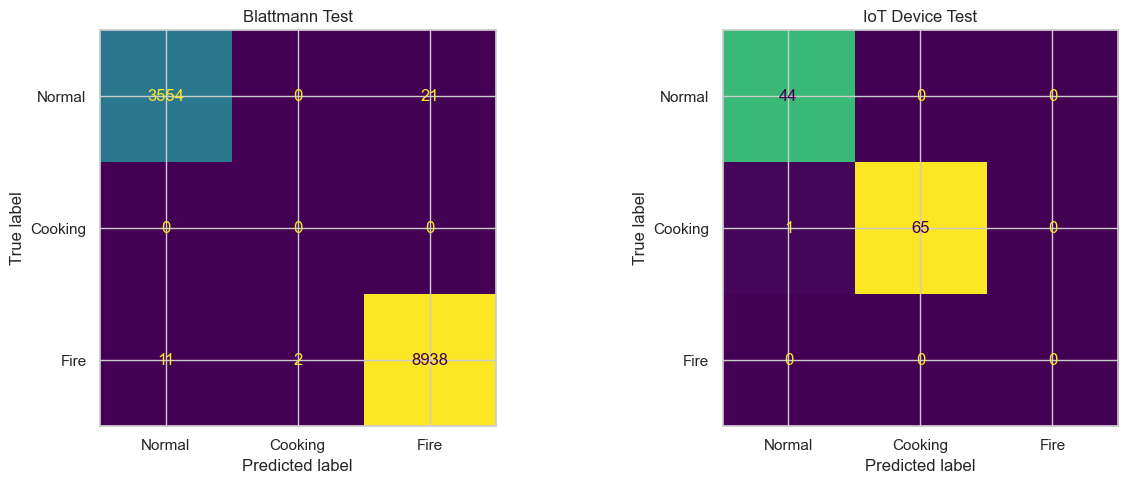

Cooking -> Fire errors in IoT: 0


In [39]:
# Plot confusion matrices for both test sets.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_blattmann_test, y_blattmann_pred, 'Blattmann Test'),
    (axes[1], y_iot_test, y_iot_pred, 'IoT Device Test'),
]:
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

print('Cooking -> Fire errors in IoT:', confusion_matrix(y_iot_test, y_iot_pred, labels=[0, 1, 2])[1][2])


#### 11. Feature Importance

This shows which features the Random Forest used most.


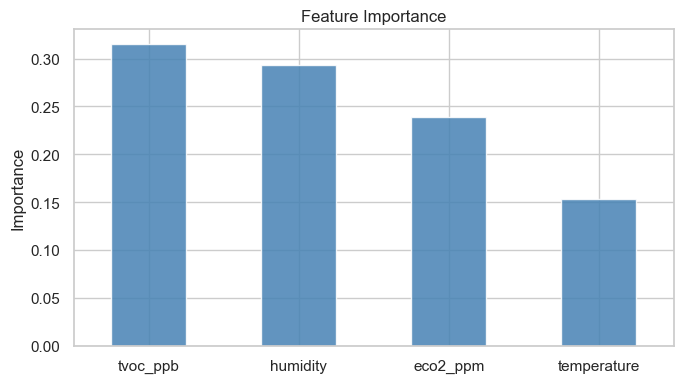

tvoc_ppb       0.3147
humidity       0.2936
eco2_ppm       0.2388
temperature    0.1528


In [40]:
# Display Random Forest feature importance.
feature_importance = pd.Series(random_forest.feature_importances_, index=feature_col).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
feature_importance.plot(kind='bar', color='steelblue', alpha=0.85)
plt.title('Feature Importance')
plt.ylabel('Importance')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(feature_importance.round(4).to_string())


#### 12. Overfitting Check

We compare training F1-macro with cross-validation F1-macro.


In [41]:
# Check for overfitting by comparing train and cross-validation scores.
train_f1 = f1_score(y_train, random_forest.predict(X_train_sc), average='macro')
cv_f1 = cv_scores.mean()
gap = train_f1 - cv_f1

print(f'Train F1: {train_f1:.4f}  |  CV F1: {cv_f1:.4f}  |  Gap: {gap:.4f}')
print('no overfitting' if gap < 0.02 else 'mild overfitting' if gap < 0.05 else 'overfitting detected')


Train F1: 1.0000  |  CV F1: 0.9943  |  Gap: 0.0057
no overfitting


#### 13. Final Notes

This notebook is based on mocked data and from our iot device and we will improve our model using more precise data.
